<a href="https://colab.research.google.com/github/GScaramussa/Redes/blob/main/redestrab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1) Arquivo de simulação “aloha.m”



Duração de 1 quadro : 1.0000 ms
Duração de 1 tick   : 10.0000 µs
Ticks por quadro    : 100
Total de ticks      : 10000
Pontos simulados    : 20
Pure ALOHA simulado!
Slotted ALOHA simulado!
Pure ALOHA   — pico de entregues: 17.4 quadros
Slotted ALOHA — pico de entregues: 38.4 quadros

Ganho do Slotted sobre o Pure: 2.21x  (teórico: 2x)


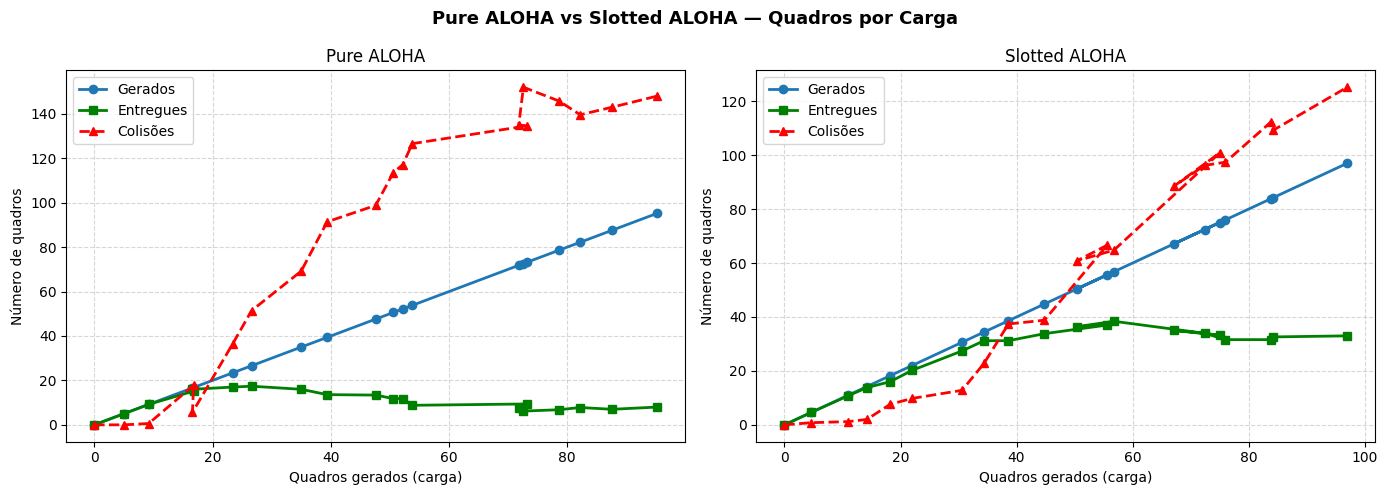

In [7]:
# -*- coding: utf-8 -*-
"""simulacao_aloha_pure_vs_slotted.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1fu9VRUCttvMAr3FZX92mzT8qXZRx3yAu

# Simulação do Protocolo ALOHA
## Pure ALOHA vs Slotted ALOHA

---

## O que é o ALOHA?

O **ALOHA** é um protocolo de acesso ao meio compartilhado criado na Universidade do Havaí nos anos 1970.
O problema que ele resolve é simples: **como múltiplas estações compartilham um único canal sem coordenação central?**

Existem duas variantes:

| | Pure ALOHA | Slotted ALOHA |
|---|---|---|
| **Quando transmite?** | A qualquer momento | Só no início de um slot |
| **Colisão ocorre quando...** | Quadros se sobrepõem parcialmente | Dois quadros ocupam o mesmo slot |
| **Throughput máximo teórico** | 1/(2e) ≈ **18,4%** | 1/e ≈ **36,8%** |

Esta simulação implementa **as duas variantes** e compara os resultados.

---
## Célula 1 — Importação das bibliotecas
"""

import matplotlib.pyplot as plt
import numpy as np

"""---
## Célula 2 — Parâmetros da rede

Definimos as características físicas do canal e das estações.
Esses parâmetros são **iguais para ambas as variantes**, permitindo comparação justa.
"""

tempo      = 0.1    # duração total da simulação (segundos)
n_est      = 10     # número de estações na rede
taxa_bits  = 1e5    # velocidade do canal: 100.000 bits/segundo
tam_quadro = 100    # tamanho de cada quadro: 100 bits


t_quadro   = tam_quadro / taxa_bits        # tempo para transmitir 1 quadro (s)
dt_sim     = t_quadro / tam_quadro         # duração de 1 tick (passo mínimo de tempo)
t_sim      = int(np.ceil(tempo / dt_sim))  # total de ticks na simulação
duracao_tx = int(np.ceil(t_quadro / dt_sim))  # quantos ticks dura 1 transmissão

taxa_max_quadro = int(np.ceil(taxa_bits / tam_quadro / n_est))
passo           = max(1, int(np.ceil(taxa_max_quadro / 20)))  # ~20 pontos no gráfico

print(f"Duração de 1 quadro : {t_quadro*1000:.4f} ms")
print(f"Duração de 1 tick   : {dt_sim*1e6:.4f} µs")
print(f"Ticks por quadro    : {duracao_tx}")
print(f"Total de ticks      : {t_sim}")
print(f"Pontos simulados    : {len(range(0, taxa_max_quadro, passo))}")

"""---
## Célula 3 — Pure ALOHA

### Como funciona?

No **Pure ALOHA**, a estação transmite **imediatamente** assim que um quadro chega, sem verificar o canal e sem esperar qualquer sincronização de tempo.

```
Estação A: ──[quadro A]────────────────────
Estação B: ──────[quadro B]────────────────
Canal:     ──[  COLISÃO  ]─────────────────
```

A colisão acontece sempre que dois quadros se **sobrepõem no tempo**, mesmo que parcialmente.
Por isso a **janela de vulnerabilidade** é de **2 × duração do quadro** — o dobro do Slotted.

### Regras da simulação:
1. Quadro chegou + canal livre → **transmite imediatamente**
2. Quadro chegou + canal ocupado → **enfileira**
3. Transmissão terminou com colisão → **backoff aleatório** e retransmite
4. Transmissão terminou sem colisão → **entregue com sucesso**
"""

# vetores de resultado do Pure ALOHA
pure_gerados      = np.zeros(taxa_max_quadro)
pure_entregues    = np.zeros(taxa_max_quadro)
pure_colididos    = np.zeros(taxa_max_quadro)

for taxa_quadro in range(0, taxa_max_quadro, passo):

    tm_q       = taxa_quadro * dt_sim   # probabilidade de chegada por tick
    espera_max = 10 * duracao_tx        # backoff máximo em ticks
    rodadas    = 5

    for r in range(rodadas):

        tx_ativo  = np.zeros(n_est)
        tx_fila   = np.zeros(n_est)
        tx_cnt    = np.zeros(n_est)
        tx_espera = np.zeros(n_est)
        colin     = np.zeros(n_est)

        chegada_quadros = 0
        colisoes        = 0
        entregues       = 0

        for k in range(t_sim):
            for j in range(n_est):

                # decrementa contador de transmissão
                if tx_cnt[j] > 0:
                    tx_cnt[j] -= 1

                # transmissão terminou?
                if tx_cnt[j] == 0 and tx_ativo[j] == 1:
                    tx_ativo[j] = 0
                    if colin[j] == 1:
                        # colisão → backoff aleatório
                        tx_espera[j] = int(np.ceil(espera_max * np.random.rand()))
                        tx_fila[j]  += 1
                        colin[j]     = 0
                        colisoes    += 1
                    else:
                        entregues += 1  # entregue com sucesso

                # estação ociosa: tenta transmitir
                if tx_ativo[j] == 0:
                    if tx_espera[j] > 0:
                        tx_espera[j] -= 1
                    elif tx_fila[j] > 0:
                        tx_ativo[j] = 1
                        tx_cnt[j]   = duracao_tx
                        tx_fila[j] -= 1

                # ── PURE ALOHA: transmite IMEDIATAMENTE quando quadro chega ──
                if np.random.rand() < tm_q:
                    chegada_quadros += 1
                    if tx_ativo[j] == 0 and tx_espera[j] == 0:
                        tx_ativo[j] = 1          # sem esperar slot — transmite agora
                        tx_cnt[j]   = duracao_tx
                    else:
                        tx_fila[j] += 1

            # detecta colisão: mais de 1 estação transmitindo
            if np.sum(tx_ativo) > 1:
                for j in range(n_est):
                    if tx_ativo[j] == 1:
                        colin[j] = 1

        pure_gerados[taxa_quadro]   += chegada_quadros / rodadas
        pure_entregues[taxa_quadro] += entregues / rodadas
        pure_colididos[taxa_quadro] += colisoes / rodadas

print("Pure ALOHA simulado!")

"""---
## Célula 4 — Slotted ALOHA

### Como funciona?

No **Slotted ALOHA**, o tempo é dividido em **slots** do tamanho exato de um quadro.
As estações são **sincronizadas** e só podem começar a transmitir no **início de um slot**.

```
Tempo:     |── slot ──|── slot ──|── slot ──|
Estação A: |[quadro A]|          |          |
Estação B: |          |[quadro B]|          |
Canal:     | sucesso! |  sucesso!|  vazio   |
```

Como todos começam no mesmo instante, ou dois quadros colidem **completamente** (mesmo slot)
ou não colidem de jeito nenhum. Isso reduz a janela de vulnerabilidade à metade.

### Diferença na implementação:
A única mudança em relação ao Pure ALOHA é esta condição:

```python
inicio_slot = (k % duracao_tx == 0)  # só transmite no início do slot
```

"""

# vetores de resultado do Slotted ALOHA
slot_gerados      = np.zeros(taxa_max_quadro)
slot_entregues    = np.zeros(taxa_max_quadro)
slot_colididos    = np.zeros(taxa_max_quadro)

for taxa_quadro in range(0, taxa_max_quadro, passo):

    tm_q       = taxa_quadro * dt_sim
    espera_max = 10 * duracao_tx
    rodadas    = 5

    for r in range(rodadas):

        tx_ativo  = np.zeros(n_est)
        tx_fila   = np.zeros(n_est)
        tx_cnt    = np.zeros(n_est)
        tx_espera = np.zeros(n_est)
        colin     = np.zeros(n_est)

        chegada_quadros = 0
        colisoes        = 0
        entregues       = 0

        for k in range(t_sim):

            # ── SLOTTED ALOHA: só permite iniciar transmissão no início do slot ──
            inicio_slot = (k % duracao_tx == 0)

            for j in range(n_est):

                # decrementa contador de transmissão
                if tx_cnt[j] > 0:
                    tx_cnt[j] -= 1

                # transmissão terminou?
                if tx_cnt[j] == 0 and tx_ativo[j] == 1:
                    tx_ativo[j] = 0
                    if colin[j] == 1:
                        # colisão → backoff aleatório (múltiplo de slot)
                        n_slots_espera = int(np.ceil(10 * np.random.rand()))
                        tx_espera[j]   = n_slots_espera * duracao_tx
                        tx_fila[j]    += 1
                        colin[j]       = 0
                        colisoes      += 1
                    else:
                        entregues += 1

                # estação ociosa: tenta transmitir (apenas no início do slot)
                if tx_ativo[j] == 0 and inicio_slot:
                    if tx_espera[j] > 0:
                        tx_espera[j] -= duracao_tx
                    elif tx_fila[j] > 0:
                        tx_ativo[j] = 1
                        tx_cnt[j]   = duracao_tx
                        tx_fila[j] -= 1

                # chegada de novo quadro
                if np.random.rand() < tm_q:
                    chegada_quadros += 1
                    # ── SLOTTED: só começa a transmitir se for início de slot ──
                    if tx_ativo[j] == 0 and tx_espera[j] == 0 and inicio_slot:
                        tx_ativo[j] = 1
                        tx_cnt[j]   = duracao_tx
                    else:
                        tx_fila[j] += 1  # aguarda o próximo slot

            # detecta colisão
            if np.sum(tx_ativo) > 1:
                for j in range(n_est):
                    if tx_ativo[j] == 1:
                        colin[j] = 1

        slot_gerados[taxa_quadro]   += chegada_quadros / rodadas
        slot_entregues[taxa_quadro] += entregues / rodadas
        slot_colididos[taxa_quadro] += colisoes / rodadas

print("Slotted ALOHA simulado!")

"""---
## Célula 5 — Preparação dos dados

Extraímos apenas os pontos simulados e calculamos o **throughput normalizado** de cada variante.

O throughput normalizado divide os quadros entregues pelo **melhor resultado possível**,
colocando ambas as curvas na mesma escala (0 a 1) para comparação direta com a teoria.
"""

indices = list(range(0, taxa_max_quadro, passo))

# Pure ALOHA
p_gerados    = [pure_gerados[i]   for i in indices]
p_entregues  = [pure_entregues[i] for i in indices]
p_colididos  = [pure_colididos[i] for i in indices]
max_pure     = max(p_entregues) if max(p_entregues) > 0 else 1
p_throughput = [e / max_pure for e in p_entregues]

# Slotted ALOHA
s_gerados    = [slot_gerados[i]   for i in indices]
s_entregues  = [slot_entregues[i] for i in indices]
s_colididos  = [slot_colididos[i] for i in indices]
max_slot     = max(s_entregues) if max(s_entregues) > 0 else 1
s_throughput = [e / max_slot for e in s_entregues]

print(f"Pure ALOHA   — pico de entregues: {max_pure:.1f} quadros")
print(f"Slotted ALOHA — pico de entregues: {max_slot:.1f} quadros")
print(f"\nGanho do Slotted sobre o Pure: {max_slot/max_pure:.2f}x  (teórico: 2x)")

"""---
## Célula 6 — Gráfico: Quadros entregues e colisões

"""

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Pure ALOHA vs Slotted ALOHA — Quadros por Carga",
             fontsize=13, fontweight="bold")

# ── Pure ALOHA ──
ax1 = axes[0]
ax1.set_title("Pure ALOHA", fontsize=12)
ax1.plot(p_gerados, p_gerados,   label="Gerados",  marker="o", linewidth=2)
ax1.plot(p_gerados, p_entregues, label="Entregues", marker="s", linewidth=2, color="green")
ax1.plot(p_gerados, p_colididos, label="Colisões",  marker="^", linewidth=2,
         linestyle="--", color="red")
ax1.set_xlabel("Quadros gerados (carga)")
ax1.set_ylabel("Número de quadros")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.5)

# ── Slotted ALOHA ──
ax2 = axes[1]
ax2.set_title("Slotted ALOHA", fontsize=12)
ax2.plot(s_gerados, s_gerados,   label="Gerados",  marker="o", linewidth=2)
ax2.plot(s_gerados, s_entregues, label="Entregues", marker="s", linewidth=2, color="green")
ax2.plot(s_gerados, s_colididos, label="Colisões",  marker="^", linewidth=2,
         linestyle="--", color="red")
ax2.set_xlabel("Quadros gerados (carga)")
ax2.set_ylabel("Número de quadros")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

 ## Fluxograma explicando como a simulação é realizada. E as diferenças da simulação em comparação com a situação real.


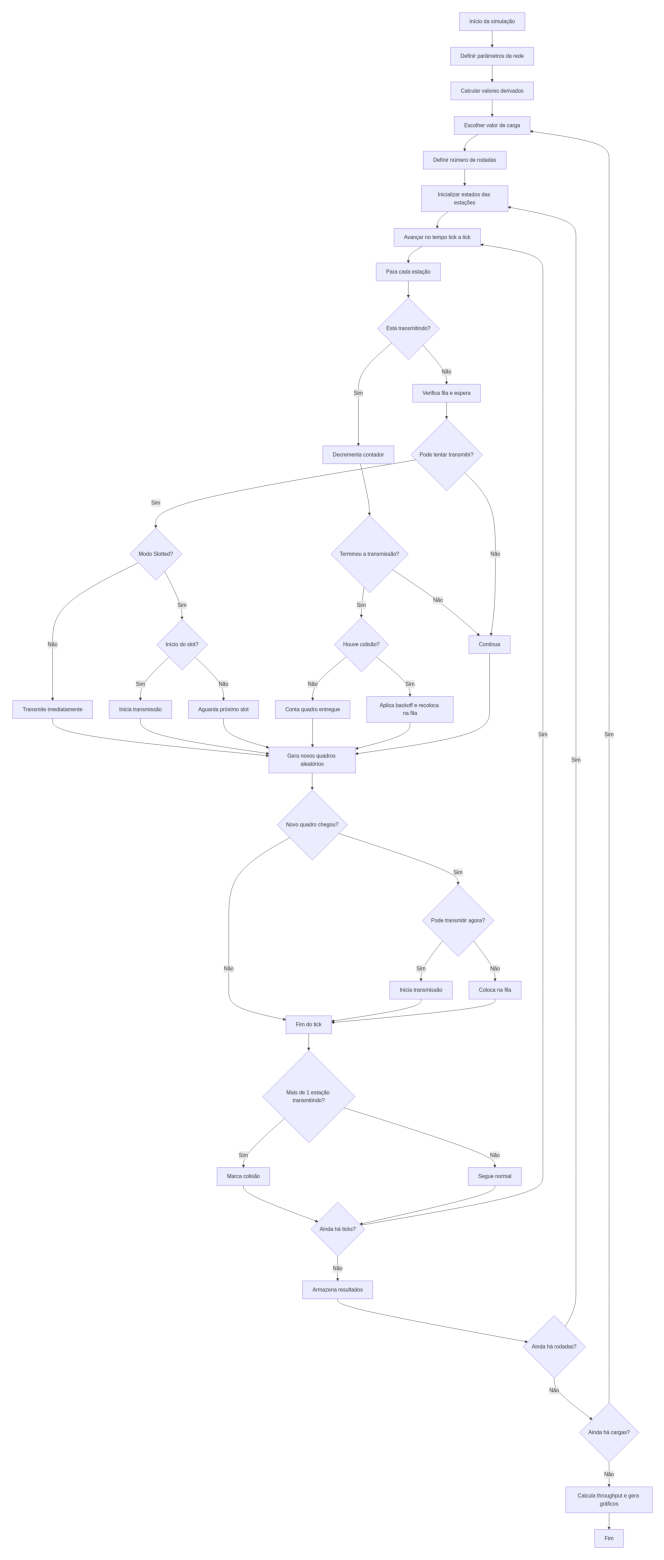

In [8]:
import base64
import io
import requests
import matplotlib.pyplot as plt
from PIL import Image

graph = r"""
flowchart TD
    A[Início da simulação] --> B[Definir parâmetros da rede]
    B --> C[Calcular valores derivados]
    C --> D[Escolher valor de carga]
    D --> E[Definir número de rodadas]
    E --> F[Inicializar estados das estações]
    F --> G[Avançar no tempo tick a tick]

    G --> H[Para cada estação]
    H --> I{Está transmitindo?}

    I -- Sim --> J[Decrementa contador]
    J --> K{Terminou a transmissão?}
    K -- Sim --> L{Houve colisão?}
    L -- Sim --> M[Aplica backoff e recoloca na fila]
    L -- Não --> N[Conta quadro entregue]
    K -- Não --> O[Continua]

    I -- Não --> P[Verifica fila e espera]
    P --> Q{Pode tentar transmitir?}
    Q -- Sim --> R{Modo Slotted?}
    R -- Não --> S[Transmite imediatamente]
    R -- Sim --> T{Início do slot?}
    T -- Sim --> U[Inicia transmissão]
    T -- Não --> V[Aguarda próximo slot]
    Q -- Não --> O

    S --> W[Gera novos quadros aleatórios]
    U --> W
    V --> W
    N --> W
    M --> W
    O --> W

    W --> X{Novo quadro chegou?}
    X -- Não --> Y[Fim do tick]
    X -- Sim --> Z{Pode transmitir agora?}
    Z -- Sim --> AA[Inicia transmissão]
    Z -- Não --> AB[Coloca na fila]

    AA --> Y
    AB --> Y

    Y --> AC{Mais de 1 estação transmitindo?}
    AC -- Sim --> AD[Marca colisão]
    AC -- Não --> AE[Segue normal]

    AD --> AF{Ainda há ticks?}
    AE --> AF
    AF -- Sim --> G
    AF -- Não --> AG[Armazena resultados]

    AG --> AH{Ainda há rodadas?}
    AH -- Sim --> F
    AH -- Não --> AI{Ainda há cargas?}
    AI -- Sim --> D
    AI -- Não --> AJ[Calcula throughput e gera gráficos]
    AJ --> AK[Fim]
"""

graphbytes = graph.encode("utf8")
base64_bytes = base64.urlsafe_b64encode(graphbytes)
base64_string = base64_bytes.decode("ascii")

url = f"https://mermaid.ink/img/{base64_string}?type=png&bgColor=!white"

img = Image.open(io.BytesIO(requests.get(url).content))
plt.figure(figsize=(16, 20))
plt.imshow(img)
plt.axis("off")
plt.show()

A simulação representa várias estações compartilhando um mesmo canal e disputando o envio de quadros. Inicialmente, são definidos os parâmetros básicos da rede, como tempo total de simulação, número de estações, taxa de transmissão e tamanho do quadro. A partir disso, o programa calcula o tempo necessário para transmitir um quadro, o passo mínimo de tempo da simulação e a quantidade total de instantes simulados. Em seguida, a carga oferecida ao canal é variada em vários níveis, de modo que seja possível observar o comportamento do protocolo sob diferentes intensidades de tráfego.
Para cada valor de carga, a simulação é repetida em várias rodadas. Em cada rodada, cada estação possui estados internos que indicam se ela está transmitindo, quantos quadros estão em fila, quanto tempo ainda falta para terminar uma transmissão e quanto tempo de espera aleatória resta após uma colisão. A cada tick da simulação, o programa percorre todas as estações e atualiza esses estados. Quando uma transmissão termina, o algoritmo verifica se houve colisão. Em caso positivo, o quadro retorna para a fila e a estação aguarda um tempo aleatório antes de tentar novamente. Caso contrário, o quadro é contabilizado como entregue com sucesso.
No Pure ALOHA, quando um novo quadro chega a uma estação, ela transmite imediatamente, desde que não esteja ocupada ou em espera. Se já estiver ocupada, o quadro é enfileirado. Já no Slotted ALOHA, essa regra muda: a estação só pode iniciar transmissão no começo de um slot, isto é, em instantes sincronizados com a duração de um quadro. Por isso, no código, a diferença principal é a verificação da condição inicio_slot, que restringe os instantes possíveis de transmissão.
Após atualizar todas as estações em um tick, o programa verifica se há mais de uma estação transmitindo ao mesmo tempo. Se isso ocorrer, todas as transmissões ativas daquele instante são marcadas como colisão. Ao final de todas as rodadas e de todos os níveis de carga, a simulação calcula os quadros gerados, entregues e colididos, além do throughput normalizado, e então gera os gráficos comparativos entre Pure ALOHA e Slotted ALOHA.
Diferenças entre a simulação e a situação real

A simulação é uma simplificação do funcionamento real de uma rede. Primeiro, ela assume que todas as estações são idênticas, usam a mesma taxa de transmissão e sempre enviam quadros do mesmo tamanho. Em uma rede real, podem existir variações de tamanho de pacote, tempos de processamento diferentes e comportamentos distintos entre dispositivos.

Além disso, o modelo considera geração de quadros aleatória idealizada, por meio de números aleatórios, o que facilita a análise estatística, mas não representa perfeitamente o tráfego real de uma rede, que costuma apresentar rajadas, períodos de ociosidade e correlações temporais.

Outro ponto é que a simulação trata a colisão de forma perfeita e instantânea: sempre que duas ou mais estações transmitem ao mesmo tempo, a colisão é detectada logicamente e todos os quadros envolvidos são marcados como falhos. Na prática, a rede pode ter atrasos de propagação, variações no meio físico, ruído, interferência e até efeitos de captura, que não aparecem nesse modelo.

Também não são considerados elementos importantes de sistemas reais, como atraso de propagação entre nós, erros de bit independentes de colisão, confirmação por ACK, temporizadores de timeout, limites de retransmissão e restrições de buffer. O código trabalha com filas e backoff de forma simplificada, apenas para observar o comportamento global dos protocolos.

Por fim, a simulação do Slotted ALOHA assume sincronização perfeita entre as estações, de modo que todas conhecem exatamente o início de cada slot. Em uma situação real, essa sincronização exige mecanismos adicionais de relógio e controle, o que aumenta a complexidade do sistema.

In [9]:
def simular_message_parametrizado(
    tempo=0.1,
    n_est=10,
    taxa_bits=1e5,
    tam_quadro=100,
    espera_factor=10,
    rodadas=5,
    seed=None
):
    if seed is not None:
        np.random.seed(seed)

    t_quadro   = tam_quadro / taxa_bits
    dt_sim     = t_quadro / tam_quadro
    t_sim      = int(np.ceil(tempo / dt_sim))
    duracao_tx = int(np.ceil(t_quadro / dt_sim))

    taxa_max_quadro = int(np.ceil(taxa_bits / tam_quadro / n_est))
    passo           = max(1, int(np.ceil(taxa_max_quadro / 20)))

    pure_gerados      = np.zeros(taxa_max_quadro)
    pure_entregues    = np.zeros(taxa_max_quadro)
    pure_colididos    = np.zeros(taxa_max_quadro)

    for taxa_quadro in range(0, taxa_max_quadro, passo):

        tm_q       = taxa_quadro * dt_sim
        espera_max = espera_factor * duracao_tx

        for r in range(rodadas):

            tx_ativo  = np.zeros(n_est)
            tx_fila   = np.zeros(n_est)
            tx_cnt    = np.zeros(n_est)
            tx_espera = np.zeros(n_est)
            colin     = np.zeros(n_est)

            chegada_quadros = 0
            colisoes        = 0
            entregues       = 0

            for k in range(t_sim):
                for j in range(n_est):

                    if tx_cnt[j] > 0:
                        tx_cnt[j] -= 1

                    if tx_cnt[j] == 0 and tx_ativo[j] == 1:
                        tx_ativo[j] = 0
                        if colin[j] == 1:
                            tx_espera[j] = int(np.ceil(espera_max * np.random.rand()))
                            tx_fila[j]  += 1
                            colin[j]     = 0
                            colisoes    += 1
                        else:
                            entregues += 1

                    if tx_ativo[j] == 0:
                        if tx_espera[j] > 0:
                            tx_espera[j] -= 1
                        elif tx_fila[j] > 0:
                            tx_ativo[j] = 1
                            tx_cnt[j]   = duracao_tx
                            tx_fila[j] -= 1

                    if np.random.rand() < tm_q:
                        chegada_quadros += 1
                        if tx_ativo[j] == 0 and tx_espera[j] == 0:
                            tx_ativo[j] = 1
                            tx_cnt[j]   = duracao_tx
                        else:
                            tx_fila[j] += 1

                if np.sum(tx_ativo) > 1:
                    for j in range(n_est):
                        if tx_ativo[j] == 1:
                            colin[j] = 1

            pure_gerados[taxa_quadro]   += chegada_quadros / rodadas
            pure_entregues[taxa_quadro] += entregues / rodadas
            pure_colididos[taxa_quadro] += colisoes / rodadas

    slot_gerados      = np.zeros(taxa_max_quadro)
    slot_entregues    = np.zeros(taxa_max_quadro)
    slot_colididos    = np.zeros(taxa_max_quadro)

    for taxa_quadro in range(0, taxa_max_quadro, passo):

        tm_q       = taxa_quadro * dt_sim
        espera_max = espera_factor * duracao_tx

        for r in range(rodadas):

            tx_ativo  = np.zeros(n_est)
            tx_fila   = np.zeros(n_est)
            tx_cnt    = np.zeros(n_est)
            tx_espera = np.zeros(n_est)
            colin     = np.zeros(n_est)

            chegada_quadros = 0
            colisoes        = 0
            entregues       = 0

            for k in range(t_sim):
                inicio_slot = (k % duracao_tx == 0)

                for j in range(n_est):

                    if tx_cnt[j] > 0:
                        tx_cnt[j] -= 1

                    if tx_cnt[j] == 0 and tx_ativo[j] == 1:
                        tx_ativo[j] = 0
                        if colin[j] == 1:
                            n_slots_espera = int(np.ceil(espera_factor * np.random.rand()))
                            tx_espera[j]   = n_slots_espera * duracao_tx
                            tx_fila[j]    += 1
                            colin[j]       = 0
                            colisoes      += 1
                        else:
                            entregues += 1

                    if tx_ativo[j] == 0 and inicio_slot:
                        if tx_espera[j] > 0:
                            tx_espera[j] -= duracao_tx
                        elif tx_fila[j] > 0:
                            tx_ativo[j] = 1
                            tx_cnt[j]   = duracao_tx
                            tx_fila[j] -= 1

                    if np.random.rand() < tm_q:
                        chegada_quadros += 1
                        if tx_ativo[j] == 0 and tx_espera[j] == 0 and inicio_slot:
                            tx_ativo[j] = 1
                            tx_cnt[j]   = duracao_tx
                        else:
                            tx_fila[j] += 1

                if np.sum(tx_ativo) > 1:
                    for j in range(n_est):
                        if tx_ativo[j] == 1:
                            colin[j] = 1

            slot_gerados[taxa_quadro]   += chegada_quadros / rodadas
            slot_entregues[taxa_quadro] += entregues / rodadas
            slot_colididos[taxa_quadro] += colisoes / rodadas

    # ===== preparação dos dados =====
    indices = list(range(0, taxa_max_quadro, passo))

    p_gerados    = np.array([pure_gerados[i]   for i in indices], dtype=float)
    p_entregues  = np.array([pure_entregues[i] for i in indices], dtype=float)

    s_gerados    = np.array([slot_gerados[i]   for i in indices], dtype=float)
    s_entregues  = np.array([slot_entregues[i] for i in indices], dtype=float)

    # carga oferecida e throughput normalizado para comparar com a teoria
    capacidade_quadros = tempo / t_quadro if t_quadro > 0 else 1

    G_pure = p_gerados / capacidade_quadros
    G_slot = s_gerados / capacidade_quadros

    S_pure = p_entregues / capacidade_quadros
    S_slot = s_entregues / capacidade_quadros

    return {
        "tempo": tempo,
        "n_est": n_est,
        "taxa_bits": taxa_bits,
        "tam_quadro": tam_quadro,
        "espera_factor": espera_factor,
        "rodadas": rodadas,
        "t_quadro": t_quadro,
        "dt_sim": dt_sim,
        "t_sim": t_sim,
        "duracao_tx": duracao_tx,
        "G_pure": G_pure,
        "G_slot": G_slot,
        "S_pure": S_pure,
        "S_slot": S_slot
    }

In [10]:
def plotar_variacao_message(nome_parametro, valores, montar_kwargs, titulo):
    g = np.linspace(0, 2, 400)
    teoria_pure = g * np.exp(-2 * g)
    teoria_slot = g * np.exp(-g)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
    fig.suptitle(titulo, fontsize=13, fontweight="bold")

    axes[0].plot(g, teoria_pure, linestyle="--", linewidth=2, label="Teórico")
    axes[1].plot(g, teoria_slot, linestyle="--", linewidth=2, label="Teórico")

    for valor in valores:
        resultado = simular_message_parametrizado(**montar_kwargs(valor))

        axes[0].plot(
            resultado["G_pure"],
            resultado["S_pure"],
            marker="o",
            linewidth=2,
            label=f"{nome_parametro}={valor}"
        )

        axes[1].plot(
            resultado["G_slot"],
            resultado["S_slot"],
            marker="o",
            linewidth=2,
            label=f"{nome_parametro}={valor}"
        )

    axes[0].set_title("Pure ALOHA")
    axes[1].set_title("Slotted ALOHA")

    for ax in axes:
        ax.set_xlabel("Carga oferecida G")
        ax.set_ylabel("Throughput S")
        ax.set_xlim(0, 2)
        ax.set_ylim(0, 0.5)
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

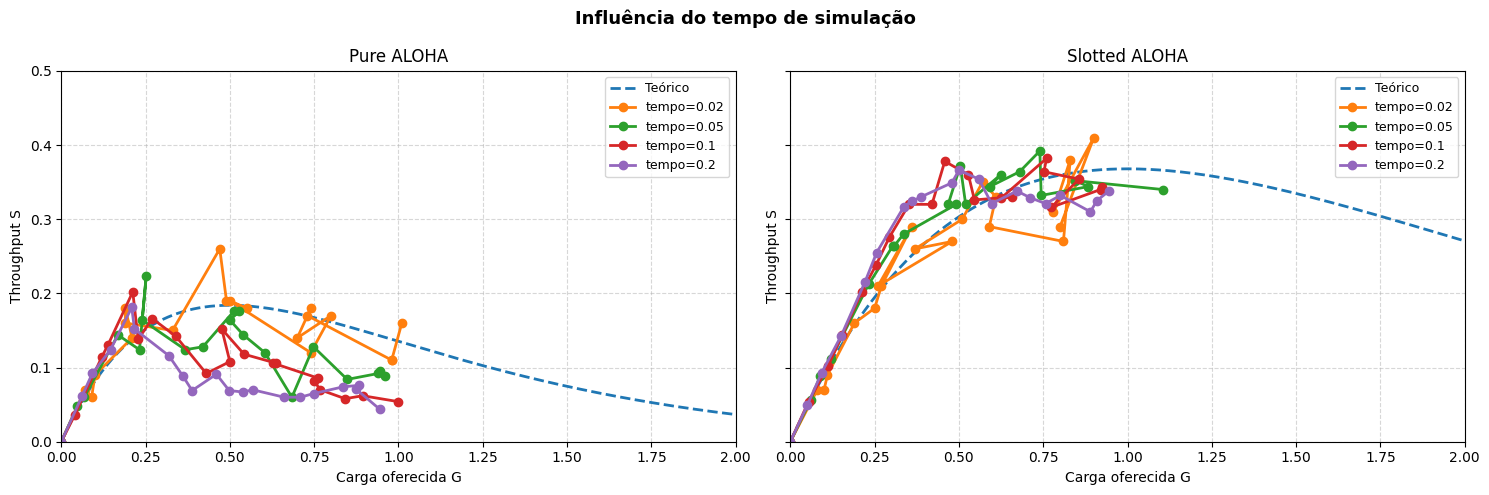

In [11]:
plotar_variacao_message(
    nome_parametro="tempo",
    valores=[0.02, 0.05, 0.1, 0.2],
    montar_kwargs=lambda v: {
        "tempo": v,
        "n_est": 10,
        "taxa_bits": 1e5,
        "tam_quadro": 100,
        "espera_factor": 10,
        "rodadas": 5,
        "seed": 42
    },
    titulo="Influência do tempo de simulação"
)


### Influência do tempo de simulação

Este gráfico mostra como a duração total da simulação afeta os resultados obtidos. Quando o tempo de simulação é menor, há menos eventos observados e os resultados tendem a oscilar mais. Quando o tempo aumenta, a curva fica mais estável e mais próxima da tendência teórica, pois a média passa a representar melhor o comportamento do protocolo.

Assim, o tempo de simulação não altera a teoria do ALOHA em si, mas altera a qualidade estatística da estimativa obtida pela simulação.

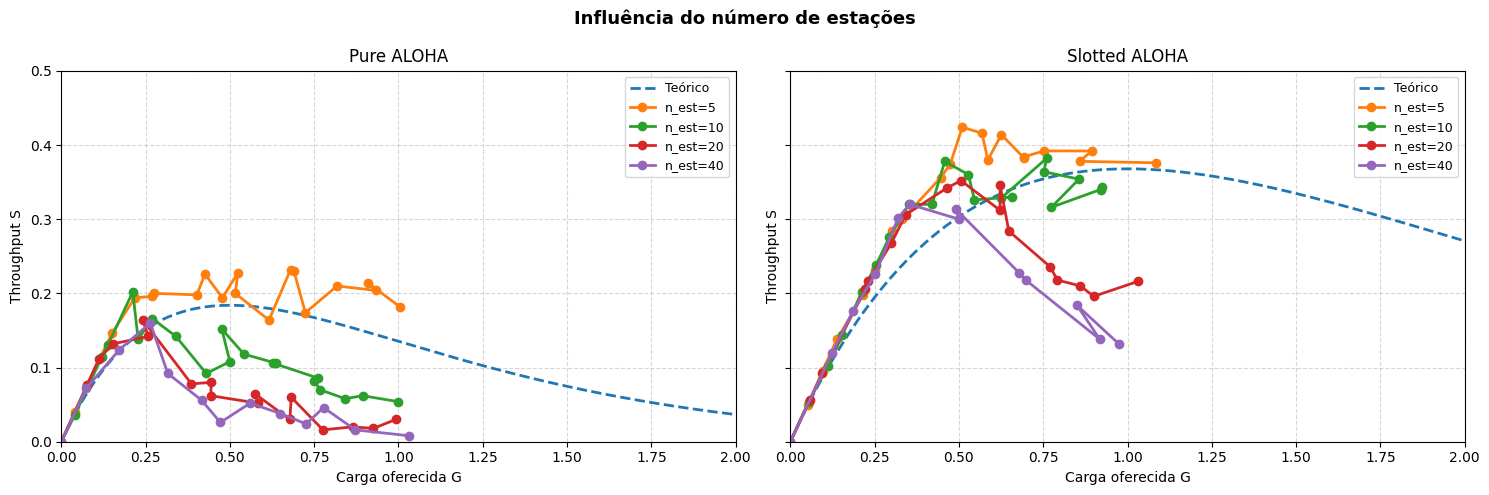

In [12]:
plotar_variacao_message(
    nome_parametro="n_est",
    valores=[5, 10, 20, 40],
    montar_kwargs=lambda v: {
        "tempo": 0.1,
        "n_est": v,
        "taxa_bits": 1e5,
        "tam_quadro": 100,
        "espera_factor": 10,
        "rodadas": 5,
        "seed": 42
    },
    titulo="Influência do número de estações"
)

### Influência do número de estações

Este gráfico mostra o efeito da quantidade de estações disputando o mesmo canal. Com poucas estações, a chance de colisão é menor e a curva tende a ser menos severa. À medida que o número de estações aumenta, cresce a competição pelo meio compartilhado e, com isso, aumenta também a probabilidade de colisões.

Dessa forma, o aumento do número de estações tende a reduzir o desempenho em cargas mais altas, principalmente no Pure ALOHA, que é mais vulnerável à sobreposição de transmissões.

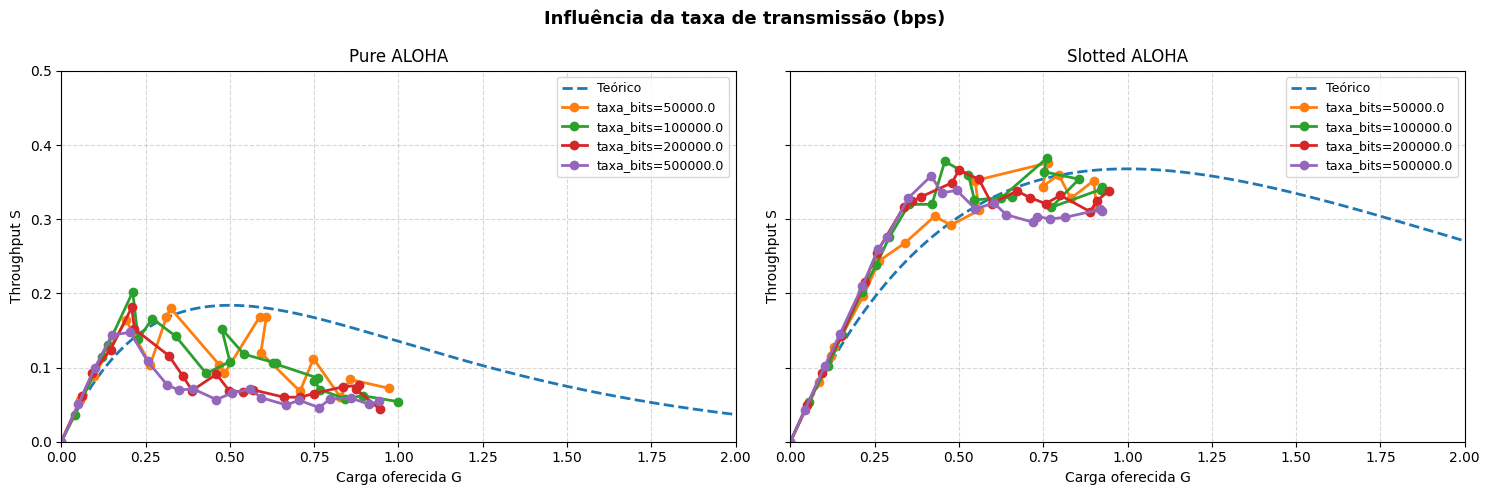

In [14]:
plotar_variacao_message(
    nome_parametro="taxa_bits",
    valores=[5e4, 1e5, 2e5, 5e5],
    montar_kwargs=lambda v: {
        "tempo": 0.1,
        "n_est": 10,
        "taxa_bits": v,
        "tam_quadro": 100,
        "espera_factor": 10,
        "rodadas": 5,
        "seed": 42
    },
    titulo="Influência da taxa de transmissão (bps)"
)

### Influência da taxa de transmissão

A taxa de transmissão altera o tempo necessário para enviar cada quadro. Quanto maior a taxa em bits por segundo, menor tende a ser o tempo de ocupação do canal por quadro. Isso influencia a dinâmica temporal da simulação e pode tornar os resultados mais estáveis.

Em termos teóricos, a forma geral das curvas não deveria mudar de maneira significativa quando a análise é feita de forma normalizada. Na prática, porém, a taxa de transmissão afeta a granularidade temporal da simulação e, por isso, pode modificar a suavidade e a dispersão dos pontos obtidos.

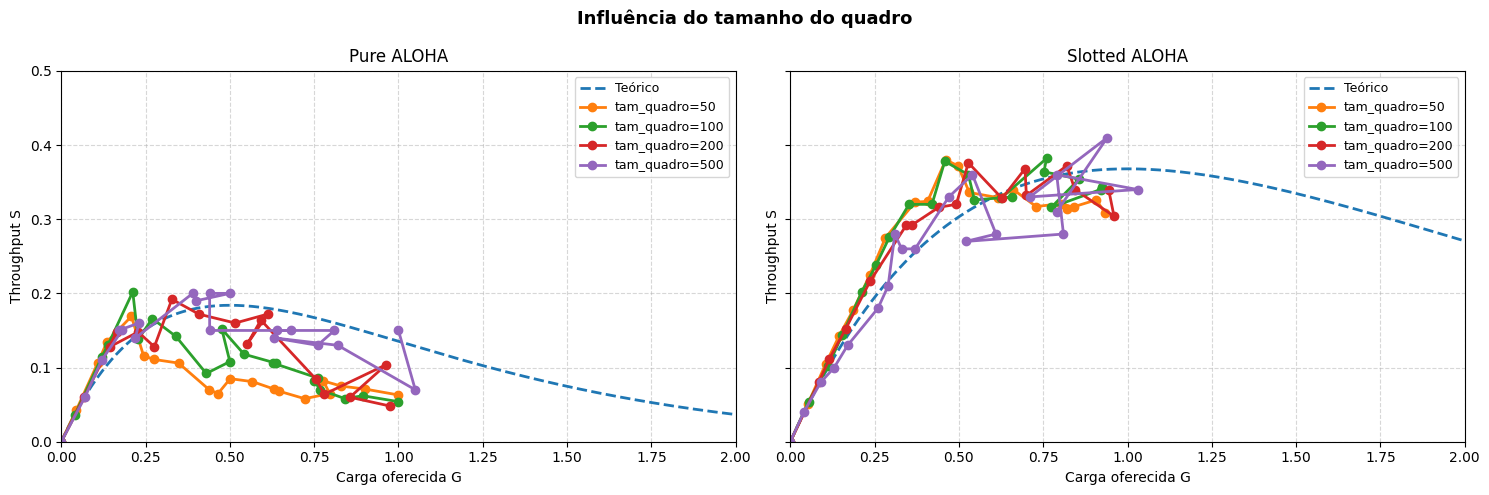

In [15]:
plotar_variacao_message(
    nome_parametro="tam_quadro",
    valores=[50, 100, 200, 500],
    montar_kwargs=lambda v: {
        "tempo": 0.1,
        "n_est": 10,
        "taxa_bits": 1e5,
        "tam_quadro": v,
        "espera_factor": 10,
        "rodadas": 5,
        "seed": 42
    },
    titulo="Influência do tamanho do quadro"
)

### Influência do tamanho do quadro

O tamanho do quadro influencia diretamente o tempo de transmissão. Quadros maiores ocupam o canal por mais tempo, aumentando a chance de colisão e tornando cada falha mais custosa. Por esse motivo, o aumento do tamanho do quadro tende a piorar o desempenho, sobretudo em cargas mais altas.

Além disso, no código utilizado, esse parâmetro também afeta a duração da transmissão e, indiretamente, a espera aleatória após colisão. Por isso, sua influência na simulação pode ser ainda mais perceptível do que no modelo teórico idealizado.

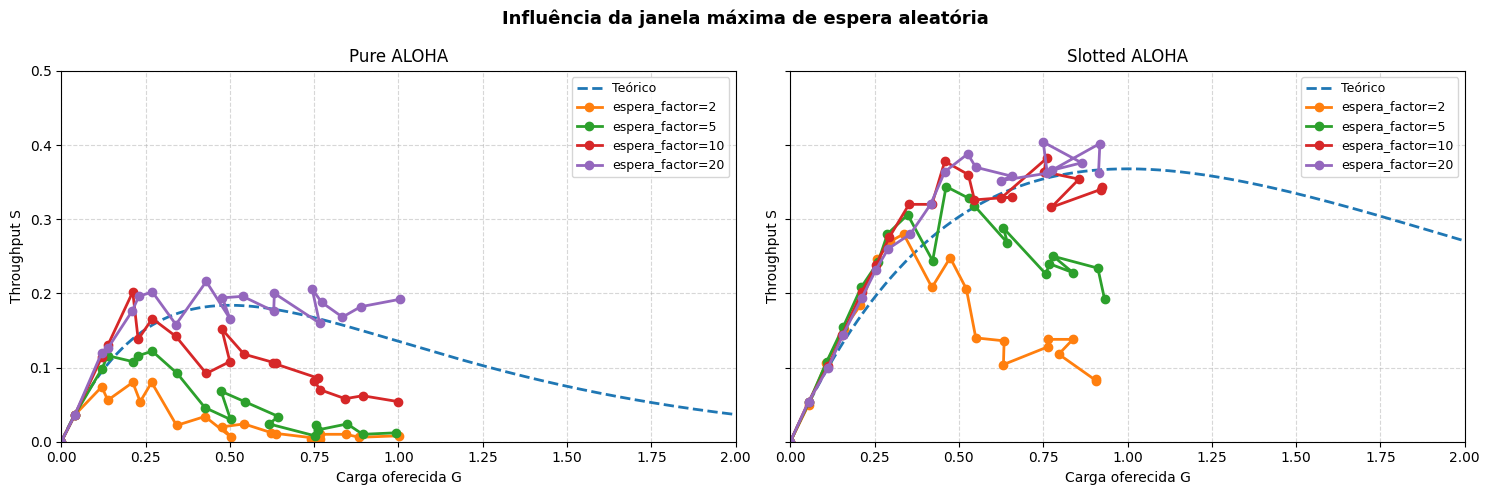

In [16]:
plotar_variacao_message(
    nome_parametro="espera_factor",
    valores=[2, 5, 10, 20],
    montar_kwargs=lambda v: {
        "tempo": 0.1,
        "n_est": 10,
        "taxa_bits": 1e5,
        "tam_quadro": 100,
        "espera_factor": v,
        "rodadas": 5,
        "seed": 42
    },
    titulo="Influência da janela máxima de espera aleatória"
)

### Influência da janela máxima de espera aleatória

Este gráfico avalia o efeito do backoff aleatório adotado após uma colisão. Quando a janela de espera é muito pequena, várias estações podem tentar retransmitir quase ao mesmo tempo, provocando novas colisões. Quando essa janela aumenta, as retransmissões ficam mais espalhadas no tempo, reduzindo a chance de recolisão imediata.

Assim, a janela de espera aleatória tem forte impacto no resultado da simulação. Ela não aparece de forma tão explícita no modelo teórico clássico, mas interfere bastante no comportamento prático do sistema simulado.

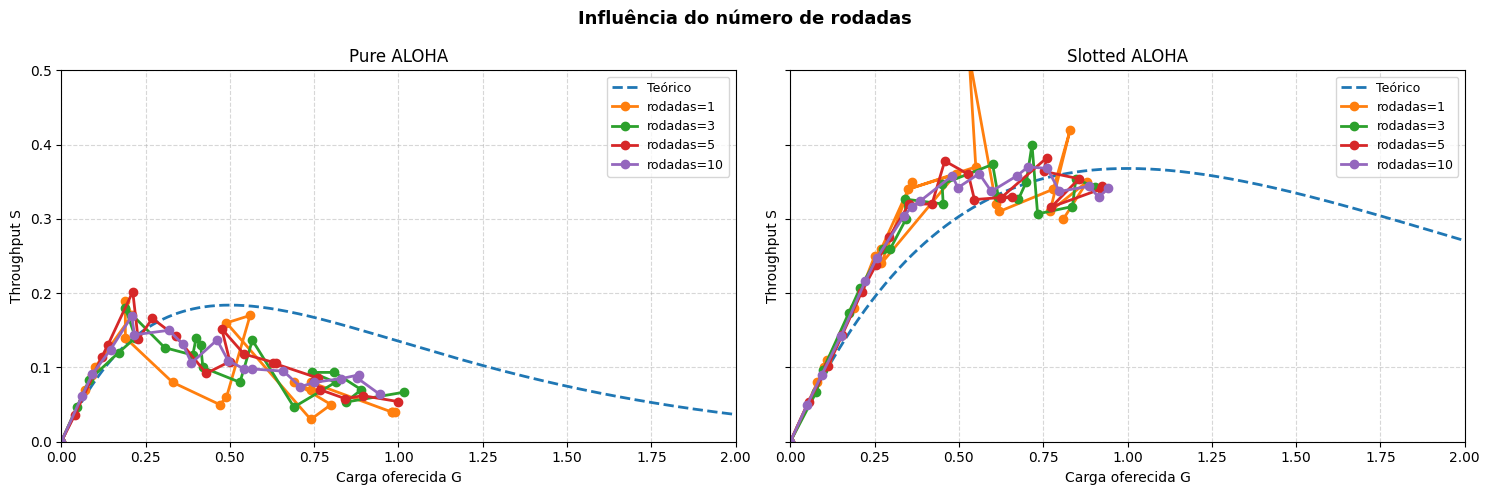

In [17]:
plotar_variacao_message(
    nome_parametro="rodadas",
    valores=[1, 3, 5, 10],
    montar_kwargs=lambda v: {
        "tempo": 0.1,
        "n_est": 10,
        "taxa_bits": 1e5,
        "tam_quadro": 100,
        "espera_factor": 10,
        "rodadas": v,
        "seed": 42
    },
    titulo="Influência do número de rodadas"
)

### Influência do número de rodadas

O número de rodadas corresponde à quantidade de vezes que a simulação é repetida para cada ponto analisado. Com poucas rodadas, os resultados ficam mais sujeitos a variações aleatórias de uma execução específica. Com mais rodadas, os valores médios se tornam mais confiáveis e as curvas ficam mais suaves.

Portanto, aumentar o número de rodadas não muda o comportamento teórico do protocolo, mas melhora a consistência dos resultados experimentais e a qualidade da comparação com a teoria.